In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/A_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/E_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/L_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/N_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/S_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/D_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test/G_test.jpg
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Datas

In [1]:
# ASL Alphabet Classifier (Deep Learning, TensorFlow)

# This notebook trains a computer-vision model on:

# debashishsau/aslamerican-sign-language-aplhabet-dataset


from pathlib import Path

import json

import random


import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt


SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


print("TensorFlow:", tf.__version__)

print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

2026-03-17 13:55:38.192534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773755738.590390      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773755738.702896      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773755739.641879      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773755739.641923      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773755739.641927      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: True


In [2]:
# ---- Dataset path configuration ----

# Option 1 (recommended): set DATASET_ROOT to your local dataset root.

# It should contain ASL_Alphabet_Dataset/asl_alphabet_train or asl_alphabet_train directly.

DATASET_ROOT = "/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/"  # Example: '/home/temi/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1'


def find_train_dir(dataset_root=None):
    candidates = []

    if dataset_root:
        root = Path(dataset_root).expanduser()

        candidates.extend(
            [
                root / "ASL_Alphabet_Dataset" / "asl_alphabet_train",
                root / "asl_alphabet_train",
            ]
        )

    workspace = Path.cwd()

    candidates.extend(
        [
            workspace / "ASL_Alphabet_Dataset" / "asl_alphabet_train",
            workspace / "asl_alphabet_train",
            Path.home()
            / ".cache"
            / "kagglehub"
            / "datasets"
            / "debashishsau"
            / "aslamerican-sign-language-aplhabet-dataset",
        ]
    )

    for c in candidates:
        if c.exists() and c.is_dir():
            if c.name == "asl_alphabet_train":
                return c

            nested = c / "ASL_Alphabet_Dataset" / "asl_alphabet_train"

            if nested.exists():
                return nested

    # Recursive fallback (slow but robust)

    search_roots = [Path.home(), workspace]

    for root in search_roots:
        try:
            for p in root.rglob("asl_alphabet_train"):
                if p.is_dir():
                    return p

        except Exception:
            pass

    return None


TRAIN_DIR = find_train_dir(DATASET_ROOT)

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Could not find `asl_alphabet_train`. Set DATASET_ROOT to your dataset location."
    )


print("Using dataset directory:")

print(TRAIN_DIR)

Using dataset directory:
/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train


In [3]:
# ---- Build train/validation datasets from directory ----

IMG_SIZE = (128, 128)

BATCH_SIZE = 32

VAL_SPLIT = 0.2


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)


class_names = train_ds.class_names

NUM_CLASSES = len(class_names)


print("Classes:", NUM_CLASSES)

print(class_names)


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 223074 files belonging to 29 classes.
Using 178460 files for training.


I0000 00:00:1773756124.648578      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773756124.654808      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 223074 files belonging to 29 classes.
Using 44614 files for validation.
Classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


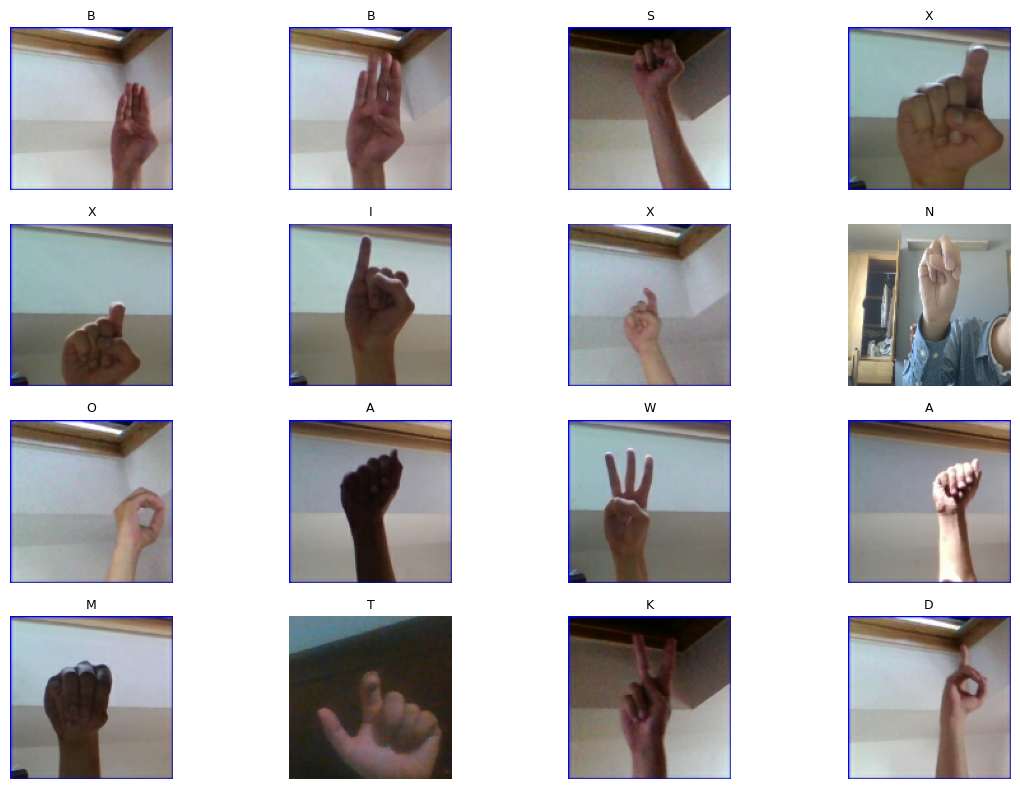

In [4]:
# ---- Visualize a sample batch ----

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(16, len(images))):
        ax = plt.subplot(4, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i])], fontsize=9)

        plt.axis("off")

plt.tight_layout()

plt.show()

In [5]:
# ---- Define a transfer-learning model (MobileNetV2) ----

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.1),
    ]
)


base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False


inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)


model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ---- Train in two stages: frozen base, then fine-tune ----

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]


EPOCHS_STAGE1 = 8

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1,
)


# Fine-tune upper layers of base model

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


EPOCHS_STAGE2 = 6

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1,
)


def merge_history(h1, h2):
    hist = {}

    for k in h1.history:
        hist[k] = h1.history[k] + h2.history.get(k, [])

    return hist


history = merge_history(history1, history2)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(history["accuracy"], label="train_acc")

plt.plot(history["val_accuracy"], label="val_acc")

plt.title("Accuracy")

plt.legend()


plt.subplot(1, 2, 2)

plt.plot(history["loss"], label="train_loss")

plt.plot(history["val_loss"], label="val_loss")

plt.title("Loss")

plt.legend()

plt.tight_layout()

plt.show()

Epoch 1/8


I0000 00:00:1773756867.199576     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


5577/5577 ━━━━━━━━━━━━━━━━━━━━ 726s 129ms/step - accuracy: 0.6081 - loss: 1.3565 - val_accuracy: 0.8594 - val_loss: 0.4640 - learning_rate: 0.0010
Epoch 2/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 202s 36ms/step - accuracy: 0.7614 - loss: 0.7814 - val_accuracy: 0.8739 - val_loss: 0.4248 - learning_rate: 0.0010
Epoch 3/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 205s 37ms/step - accuracy: 0.7699 - loss: 0.7688 - val_accuracy: 0.8685 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 4/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 202s 36ms/step - accuracy: 0.7734 - loss: 0.7614 - val_accuracy: 0.8670 - val_loss: 0.4342 - learning_rate: 0.0010
Epoch 5/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 196s 35ms/step - accuracy: 0.7905 - loss: 0.7030 - val_accuracy: 0.8869 - val_loss: 0.3753 - learning_rate: 3.0000e-04
Epoch 6/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 194s 35ms/step - accuracy: 0.7981 - loss: 0.6642 - val_accuracy: 0.8858 - val_loss: 0.3756 - learning_rate: 3.0000e-04
Epoch 7/8
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 199s 36ms/step - accurac

In [8]:
# ---- Evaluate + save model + single-image inference helper ----

val_loss, val_acc = model.evaluate(val_ds, verbose=0)

print(f"Validation loss: {val_loss:.4f}")

print(f"Validation accuracy: {val_acc:.4f}")


output_dir = Path("artifacts")

output_dir.mkdir(exist_ok=True)


model_path = output_dir / "asl_alphabet_model.keras"

labels_path = output_dir / "class_names.json"


model.save(model_path)

labels_path.write_text(json.dumps(class_names, indent=2))


print(f"Model saved to: {model_path.resolve()}")

print(f"Class names saved to: {labels_path.resolve()}")


def predict_image(image_path):
    image_path = Path(image_path)

    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)

    arr = tf.keras.utils.img_to_array(img)

    batch = tf.expand_dims(arr, axis=0)

    probs = model.predict(batch, verbose=0)[0]

    idx = int(np.argmax(probs))

    pred = class_names[idx]

    conf = float(probs[idx])

    plt.figure(figsize=(4, 4))

    plt.imshow(arr.astype("uint8"))

    plt.title(f"Pred: {pred} | Conf: {conf:.2%}")

    plt.axis("off")

    plt.show()

    return pred, conf


# Example:

# sample_image = next((TRAIN_DIR / class_names[0]).glob('*'))

# predict_image(sample_image)

Validation loss: 0.0414
Validation accuracy: 0.9868
Model saved to: /kaggle/working/artifacts/asl_alphabet_model.keras
Class names saved to: /kaggle/working/artifacts/class_names.json


In [9]:
tflite_path = output_dir / 'asl_alphabet_model_fp16.tflite'

meta_path = output_dir / 'model_meta.json'



converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()



tflite_path.write_bytes(tflite_model)

meta_path.write_text(

    json.dumps(

        {

            'img_size': IMG_SIZE,

            'class_names': class_names,

            'model_format': 'tflite_fp16'

        },

        indent=2,

    )

)



keras_size_mb = model_path.stat().st_size / (1024 * 1024)

tflite_size_mb = tflite_path.stat().st_size / (1024 * 1024)



print(f'Keras model size: {keras_size_mb:.2f} MB')

print(f'TFLite FP16 model size: {tflite_size_mb:.2f} MB')

print(f'TFLite model saved to: {tflite_path.resolve()}')

print(f'Metadata saved to: {meta_path.resolve()}')

INFO:tensorflow:Assets written to: /tmp/tmp_vx4eg3r/assets


INFO:tensorflow:Assets written to: /tmp/tmp_vx4eg3r/assets


Saved artifact at '/tmp/tmp_vx4eg3r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  136464952910352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954052624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954053008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464952905552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464952902096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954054928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954058768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464987979024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954060496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464954060688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136464987

W0000 00:00:1773761574.547886      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773761574.547937      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1773761574.683162      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
